# Run this cell / run as .py file

In [18]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
import pandas as pd
import numpy as np
import utils
from importlib import reload
# from utils import g
reload(utils)

# Your existing constants and setup
minutes_interval = 2
NOx_lb_hp_hr = 0.024
CO_lb_hp_hr = 0.0055
SOx_lb_hp_hr = 0.00809
CO2_lb_hp_hr = 1.16
PM_lb_hp_hr = 0.0007
kwh_to_hp_hr = 1.341
lb_to_gr = 453.592

emissions = ['NOx', 'CO', 'SOx', 'CO2', 'PM']

# Your existing site setup (keeping your original paths and configuration)
sites = ["Ndosho", "Walikale", "Kitatumba", "Katwa"]
root_path = "/Users/sylviaimanirakiza/Documents/GitHub/"
data_paths = [f"{root_path}Generator_ML_Emission_Modeling/data/0. ChCbNdosho/training",
            f"{root_path}Generator_ML_Emission_Modeling/data/1. Combination 1_Walikale/training",
              f"{root_path}Generator_ML_Emission_Modeling/data/5. Combination 5/training/kitatumba",
                f"{root_path}Generator_ML_Emission_Modeling/data/5. Combination 5/training/katwa"]

site_columns_oi = {
   "Walikale":[['Frequency 09B35150 (Hgr Walikale - Lab)',
                        'Frequency 64B734C2 (Hgr Walikale - Cabane)',
                        'Voltage 09B35150 (Hgr Walikale - Lab)',
                        'Voltage 64B734C2 (Hgr Walikale - Cabane)'
                        ], data_paths[1] ],
     "Ndosho": [[ 'Frequency 3E2F4FD3 (Ch Cbca Bethesda Ndosho - laboratoire)',
                'Frequency C30F2E03 (Ch Cbca Bethesda Ndosho - clinique)',
                'Voltage 3E2F4FD3 (Ch Cbca Bethesda Ndosho - laboratoire)',
                'Voltage C30F2E03 (Ch Cbca Bethesda Ndosho - clinique)'
                ],data_paths[0]],
      "Katwa":[['Frequency 1C712FB8 (Hgr Katwa - Labo)',
                'Frequency AEBA416D (Hgr Katwa - Cabine)',
                'Voltage 1C712FB8 (Hgr Katwa - Labo)',
                'Voltage AEBA416D (Hgr Katwa - Cabine)'
                ], data_paths[3]],
    "Kitatumba": [['Frequency 6EF39700 (Hgr Kitatumba - Labo)',
                   'Frequency D2B9CB2E (Hgr Kitatumba - Mdh office)',
                   'Voltage 6EF39700 (Hgr Kitatumba - Labo)',
                   'Voltage D2B9CB2E (Hgr Kitatumba - Mdh office)'
    ], data_paths[2]]
}

# Load and process data (keeping your original preprocessing)
site_names = sites 
site_dfs = {site: utils.load_data(path) for site, path in zip(site_names, data_paths)}

def rename_site_columns(df, site):
    freq_cols = site_columns_oi[site][0][:2]
    volt_cols = site_columns_oi[site][0][2:]
    rename_map = {
        freq_cols[0]: 'freq_a',
        freq_cols[1]: 'freq_b',
        volt_cols[0]: 'volt_a',
        volt_cols[1]: 'volt_b'
    }
    df = df.rename(columns=rename_map)
    df['Site'] = site
    return df

processed_dfs = []
for site, df in site_dfs.items():
    processed_df = rename_site_columns(df, site)
    processed_dfs.append(processed_df)

combined_df = pd.concat(processed_dfs, ignore_index=True)
combined_df['Time'] = pd.to_datetime(combined_df['Time'])

# Feature sets

feature_sets = {
    "Voltage and Frequency Only": ['freq_a', 'freq_b', 'volt_a', 'volt_b',],
    "Voltage, Frequency and Mean Threshold":['freq_a', 'freq_b', 'volt_a', 'volt_b',
                                             'higher_freq_lab', 'higher_freq_clinique', 'higher_volt_lab','higher_volt_clinique'
                                                ],
    "Voltage, Frequency, Mean Threshold and Time Series": ['freq_a', 'freq_b', 'volt_a', 'volt_b',
                                                        'higher_freq_lab', 'higher_freq_clinique', 'higher_volt_lab',
                                                        'higher_volt_clinique', 'Freq_delta_lab', 'Freq_delta_clinique',
                                                        'Volt_delta_lab', 'Volt_delta_clinique', 'freq_delta_negative_lab',
                                                        'freq_delta_negative_clinique', 'volt_delta_positive_lab',
                                                        'volt_delta_positive_clinique', 'freq_in_range_lab',
                                                        'volt_in_range_lab', 'freq_in_range_clinique', 'volt_in_range_clinique',
                                                        'Hour_0', 'Hour_1', 'Hour_2', 'Hour_3', 'Hour_4', 'Hour_5', 'Hour_6',
                                                        'Hour_7', 'Hour_8', 'Hour_9', 'Hour_10', 'Hour_11', 'Hour_12',
                                                        'Hour_13', 'Hour_14', 'Hour_15', 'Hour_16', 'Hour_17', 'Hour_18',
                                                        'Hour_19', 'Hour_20', 'Hour_21', 'Hour_22', 'Hour_23',
                                                        'High_delta_freq_lab', 'High_delta_freq_clinique',
                                                        'High_delta_volt_lab', 'High_delta_volt_clinique',
                                                        'Prev_High_delta_freq_lab', 'Prev_High_delta_freq_clinique',
                                                        'Prev_High_delta_volt_lab', 'Prev_High_delta_volt_clinique'],
                                                                                     
  "Voltage, Frequency, Mean threshold, TS and HMM":['freq_a', 'freq_b', 'volt_a', 'volt_b',
                                                        'higher_freq_lab', 'higher_freq_clinique', 'higher_volt_lab',
                                                        'higher_volt_clinique', 'Freq_delta_lab', 'Freq_delta_clinique',
                                                        'Volt_delta_lab', 'Volt_delta_clinique', 'freq_delta_negative_lab',
                                                        'freq_delta_negative_clinique', 'volt_delta_positive_lab',
                                                        'volt_delta_positive_clinique', 'freq_in_range_lab',
                                                        'volt_in_range_lab', 'freq_in_range_clinique', 'volt_in_range_clinique',
                                                        'Hour_0', 'Hour_1', 'Hour_2', 'Hour_3', 'Hour_4', 'Hour_5', 'Hour_6',
                                                        'Hour_7', 'Hour_8', 'Hour_9', 'Hour_10', 'Hour_11', 'Hour_12',
                                                        'Hour_13', 'Hour_14', 'Hour_15', 'Hour_16', 'Hour_17', 'Hour_18',
                                                        'Hour_19', 'Hour_20', 'Hour_21', 'Hour_22', 'Hour_23',
                                                        'High_delta_freq_lab', 'High_delta_freq_clinique',
                                                        'High_delta_volt_lab', 'High_delta_volt_clinique',
                                                        'Prev_High_delta_freq_lab', 'Prev_High_delta_freq_clinique',
                                                        'Prev_High_delta_volt_lab', 'Prev_High_delta_volt_clinique'
                                                    ]}

hmmonly = {                              
  "Voltage, Frequency, Mean threshold, TS and HMM":['freq_a', 'freq_b', 'volt_a', 'volt_b',
                                                        'higher_freq_lab', 'higher_freq_clinique', 'higher_volt_lab',
                                                        'higher_volt_clinique', 'Freq_delta_lab', 'Freq_delta_clinique',
                                                        'Volt_delta_lab', 'Volt_delta_clinique', 'freq_delta_negative_lab',
                                                        'freq_delta_negative_clinique', 'volt_delta_positive_lab',
                                                        'volt_delta_positive_clinique', 'freq_in_range_lab',
                                                        'volt_in_range_lab', 'freq_in_range_clinique', 'volt_in_range_clinique',
                                                        'Hour_0', 'Hour_1', 'Hour_2', 'Hour_3', 'Hour_4', 'Hour_5', 'Hour_6',
                                                        'Hour_7', 'Hour_8', 'Hour_9', 'Hour_10', 'Hour_11', 'Hour_12',
                                                        'Hour_13', 'Hour_14', 'Hour_15', 'Hour_16', 'Hour_17', 'Hour_18',
                                                        'Hour_19', 'Hour_20', 'Hour_21', 'Hour_22', 'Hour_23',
                                                        'High_delta_freq_lab', 'High_delta_freq_clinique',
                                                        'High_delta_volt_lab', 'High_delta_volt_clinique',
                                                        'Prev_High_delta_freq_lab', 'Prev_High_delta_freq_clinique',
                                                        'Prev_High_delta_volt_lab', 'Prev_High_delta_volt_clinique'
                                                    ]}
    

# Define hyperparameter grids
rf_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None]
}

xgb_param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 0.9, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'reg_alpha': [0, 0.1, 1],
    'reg_lambda': [1, 1.5, 2],
    'eval_metric': ['logloss'],
    'use_label_encoder': [False]
}

def tune_hyperparameters(X_train, y_train, model_type='rf', cv_folds=3, n_iter=20):
    """
    Perform hyperparameter tuning using RandomizedSearchCV
    """
    print(f"Tuning hyperparameters for {model_type}...")
    
    if model_type == 'rf':
        model = RandomForestClassifier(random_state=42, n_jobs=-1)
        param_grid = rf_param_grid
    elif model_type == 'xgb':
        model = XGBClassifier(random_state=42, eval_metric='logloss', use_label_encoder=False)
        param_grid = xgb_param_grid
    
    cv = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=42)
    
    # Use RandomizedSearchCV for efficiency
    search = RandomizedSearchCV(
        model, param_grid, n_iter=n_iter, cv=cv, 
        scoring='accuracy', n_jobs=-1, random_state=42
    )
    
    search.fit(X_train, y_train)
    
    print(f"Best {model_type} score: {search.best_score_:.4f}")
    print(f"Best {model_type} params: {search.best_params_}")
    
    return search.best_estimator_, search.best_params_

def run_experiment(train_portion=1.0, tune_hyperparams=False):
    """
    Run the experiment with different training data portions
    train_portion: 1.0 for original LOSO, 0.6 for partial data inclusion
    """
    print(f"\n{'='*60}")
    if train_portion == 1.0:
        print("RUNNING ORIGINAL LOSO (No held-out site data in training)")
    else:
        print(f"RUNNING PARTIAL DATA INCLUSION ({(1-train_portion)*100:.0f}% of held-out site in training)")
    print(f"Hyperparameter tuning: {'ON' if tune_hyperparams else 'OFF'}")
    print(f"{'='*60}")
    
    results = []
    unique_sites = combined_df['Site'].unique()
    
    # Store best parameters for each site and feature group
    best_params_cache = {}
    failed_site = []
    sites_oi = ['Walikale', 'Katwa', 'Ndosho', 'Kitatumba']

    
    for test_site in sites_oi:
        
        print(f"\n========= Leaving out {test_site} for testing =========\n")
        # try: 
        # Get the held-out site data
        held_out_data = combined_df[combined_df['Site'] == test_site].copy()
        other_sites_data = combined_df[combined_df['Site'] != test_site].copy()
        
        if train_portion < 1.0:
            # Split held-out site data
            held_out_shuffled = held_out_data.copy()
            # sample(frac=1, random_state=42).reset_index(drop=True)
            train_size = int(len(held_out_shuffled) * train_portion)
            
            # held_out_train = held_out_shuffled[:train_size]
            test_data = held_out_shuffled[train_size:]
            
            # Combine with other sites for training
            train_data = other_sites_data
            # train_data = pd.concat([other_sites_data, held_out_train], ignore_index=True)
        else:
            # Original LOSO approach
            train_data = other_sites_data
            test_data = held_out_data
        
        # Generate features
        columns_to_compare = [
            ('freq_a', 'freq_lab'),
            ('freq_b', 'freq_clinique'),
            ('volt_a', 'volt_lab'),
            ('volt_b', 'volt_clinique')
        ]
        
        train_data_ts, test_data_ts = utils.generate_group3features(
            train_data, test_data,
            columns_to_compare,
            'freq_a', 'freq_b', 'volt_a', 'volt_b'
        )
        train_data_ts_co, test_data_ts_co,hmm_features = utils.generate_group4features(train_data_ts, test_data_ts, 'freq_a', 'freq_b', 'volt_a', 'volt_b')
        print(train_data_ts_co.columns)
        print(test_data_ts_co.columns)
        print(hmm_features)
        
        # for group in ['group_1', 'group_2', 'group_3']:
        for group in feature_sets.keys():
            print(f"RUNNING FOR {group}")
            feature_columns = feature_sets[group]
            if group == "Voltage, Frequency, Mean threshold, TS and HMM":
                feature_columns = feature_columns+hmm_features
            
            train_data_model = train_data_ts_co.copy()
            test_data_model = test_data_ts_co.copy()

            # print(f"The columns for train {train_data_model};",train_data_model.columns)
            print(f"The columns for test {test_site}{len(test_data_model.columns)};",(test_data_model.columns))

            print(f"The hmm feature columns for test {test_site} ; {len(feature_columns)};",(feature_columns))

            missing_cols = set(feature_columns) - set(test_data_model.columns)
            if missing_cols:
                print(f"Warning: These columns are missing in test data: {missing_cols}")
            
            assert set(feature_columns).issubset(set(test_data_model.columns)), \
                f"Feature columns {feature_columns} are not all present in test data columns {test_data_model.columns.tolist()}"


            # Prepare data
            X_train = train_data_model[feature_columns].fillna(train_data_model[feature_columns].mean())
            y_train = train_data_model['Generator_ON']
            X_test = test_data_model[feature_columns].fillna(test_data_model[feature_columns].mean())
            y_test = test_data_model['Generator_ON']
            
            # Standardize
            scaler = StandardScaler()
            X_train_scaled = scaler.fit_transform(X_train)
            X_test_scaled = scaler.transform(X_test)
            
            # Handle XGBoost data types for group_3
            if group == "Voltage, Frequency, Mean Threshold and Time Series" or group == "Voltage, Frequency, Mean threshold, TS and HMM":
                xgb_cols = ['Prev_High_delta_freq_lab', 'Prev_High_delta_freq_clinique',
                        'Prev_High_delta_volt_lab', 'Prev_High_delta_volt_clinique']
                for col in xgb_cols:
                    if col in X_train.columns:
                        col_idx = X_train.columns.get_loc(col)
                        X_train_scaled[:, col_idx] = pd.to_numeric(X_train[col], errors='coerce').values
                        X_test_scaled[:, col_idx] = pd.to_numeric(X_test[col], errors='coerce').values
            
            # Define models
            models = {
                "LogisticRegression": LogisticRegression(max_iter=5000, random_state=42),
            }
            
            # Add tuned or default RF and XGB models
            if tune_hyperparams:
                cache_key = f"{test_site}_{group}"
                
                if f"rf_{cache_key}" not in best_params_cache:
                    rf_tuned, rf_params = tune_hyperparameters(X_train_scaled, y_train, 'rf')
                    best_params_cache[f"rf_{cache_key}"] = (rf_tuned, rf_params)
                else:
                    rf_tuned, rf_params = best_params_cache[f"rf_{cache_key}"]
                
                if f"xgb_{cache_key}" not in best_params_cache:
                    xgb_tuned, xgb_params = tune_hyperparameters(X_train_scaled, y_train, 'xgb')
                    best_params_cache[f"xgb_{cache_key}"] = (xgb_tuned, xgb_params)
                else:
                    xgb_tuned, xgb_params = best_params_cache[f"xgb_{cache_key}"]
                
                models["RandomForest_tuned"] = rf_tuned
                models["XGBoost_tuned"] = xgb_tuned
            else:
                # Use default parameters
                models["RandomForest"] = RandomForestClassifier(random_state=42)
                models["XGBoost"] = XGBClassifier(
                    random_state=42,
                    eval_metric='logloss',
                    use_label_encoder=False
                )
            
            # Train and evaluate models
            for model_name, model in models.items():
                print(f"Training {model_name} for {group} features...")
                
                # Clone the model to avoid fitting issues
                from sklearn.base import clone
                clf = clone(model)
                clf.fit(X_train_scaled, y_train)
                
                # Make predictions
                train_preds = clf.predict(X_train_scaled)
                test_preds = clf.predict(X_test_scaled)
                
                # Evaluate
                train_metrics = utils.evaluate_model_performance_model(y_train, train_preds)
                test_metrics = utils.evaluate_model_performance_model(y_test, test_preds)
                
                # Calculate generator statistics
                test_data_ts['prediction'] = test_preds
                actual_minutes, predicted_minutes = utils.display_generator_statistics(test_data_ts)
                
                # Get feature importance
                if hasattr(clf, 'feature_importances_'):
                    importances = clf.feature_importances_
                elif hasattr(clf, 'coef_'):
                    importances = np.abs(clf.coef_).flatten()
                else:
                    importances = np.zeros(len(feature_columns))
                
                top_indices = np.argsort(importances)[::-1][:5]
                top_features = [feature_columns[i] for i in top_indices]
                top_feature_str = ', '.join(top_features)
                
                # Store results
                result = {
                    "experiment_type": "modified loso" if train_portion < 1.0 else "original_loso",
                    "heldout_site": test_site,
                    "model": model_name,
                    "featuregroup": group,
                    "hyperparameter_tuning": tune_hyperparams,
                    "top5_features": top_feature_str,
                    "trainset_size": len(X_train),
                    "testset_size": len(X_test),
                    "train_accuracy": train_metrics["Accuracy"],
                    "test_accuracy": test_metrics["Accuracy"],
                    "precision": test_metrics["Precision"],
                    "recall": test_metrics["Recall"],
                    "f1 score": test_metrics.get("F1_Score", 0),
                    "actual_mins_GENON": actual_minutes,
                    "predicted_mins_GENON": predicted_minutes,
                    "Percentage generator on-time detection error": -(100*(actual_minutes-predicted_minutes))/actual_minutes if actual_minutes > 0 else 0
                }
                results.append(result)
                
                print(f"  {model_name} | Train Acc: {train_metrics['Accuracy']:.3f} | Test Acc: {test_metrics['Accuracy']:.3f}")
        # except: 
        #     failed_site.append(test_site)
        #     continue
    return pd.DataFrame(results), failed_site

# Run experiments
print("Starting experiments...")

# results_crossval_partialintest_notuning, failed_site = run_experiment(train_portion=0.6, tune_hyperparams=False)
results_crossval_partialintest_tuning, failed_site = run_experiment(train_portion=0.6, tune_hyperparams=True)

# display(results_crossval_partialintest_notuning)
# results_crossval_partialintest_notuning.to_csv("results_crossval.csv", index=False)

Some rows are not separated by exactly 2 minutes.
Invalid rows:
Some rows are not separated by exactly 2 minutes.
Invalid rows:
Some rows are not separated by exactly 2 minutes.
Invalid rows:
Some rows are not separated by exactly 2 minutes.
Invalid rows:
Starting experiments...

RUNNING PARTIAL DATA INCLUSION (40% of held-out site in training)
Hyperparameter tuning: ON

========= Leaving out Walikale for testing =========

Index(['Time', 'freq_a', 'freq_b', 'volt_a', 'volt_b', 'Generator_ON', 'Site',
       'higher_freq_lab', 'higher_freq_clinique', 'higher_volt_lab',
       'higher_volt_clinique', 'Freq_delta_lab', 'Freq_delta_clinique',
       'Volt_delta_lab', 'Volt_delta_clinique', 'freq_delta_negative_lab',
       'freq_delta_negative_clinique', 'volt_delta_positive_lab',
       'volt_delta_positive_clinique', 'freq_in_range_lab',
       'volt_in_range_lab', 'freq_in_range_clinique', 'volt_in_range_clinique',
       'Hour_0', 'Hour_1', 'Hour_2', 'Hour_3', 'Hour_4', 'Hour_5', 'Hou

/Users/sylviaimanirakiza/Documents/GitHub/Generator_ML_Emission_Modeling/venv/lib/python3.9/site-packages/xgboost/core.py:158: UserWarning: [11:55:26] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/Users/sylviaimanirakiza/Documents/GitHub/Generator_ML_Emission_Modeling/venv/lib/python3.9/site-packages/xgboost/core.py:158: UserWarning: [11:55:26] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/Users/sylviaimanirakiza/Documents/GitHub/Generator_ML_Emission_Modeling/venv/lib/python3.9/site-packages/xgboost/core.py:158: UserWarning: [11:55:26] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/Users/sylviaimanirakiza/Documents/GitHub/Generator_ML_Emission_Modeling/venv/lib/python3.9/si

Best xgb score: 0.9788
Best xgb params: {'use_label_encoder': False, 'subsample': 0.9, 'reg_lambda': 1, 'reg_alpha': 0, 'n_estimators': 200, 'learning_rate': 0.2, 'eval_metric': 'logloss', 'colsample_bytree': 0.8}
Training LogisticRegression for Voltage and Frequency Only features...
Accuracy: 0.8361111111111111
Confusion Matrix:
[[71515    46]
 [13996   123]]
Precision: 0.727810650887574
Recall: 0.008711665132091508
Accuracy: 0.8795882936507936
Confusion Matrix:
[[7093    7]
 [ 964    0]]
Precision: 0.0
Recall: 0.0
Actual Minutes: 964 minutes, or 16.07 hours within 134.40 hours
Predicted Minutes: 7 minutes, or 0.12 hours within 134.40 hours
  LogisticRegression | Train Acc: 0.836 | Test Acc: 0.880
Training RandomForest_tuned for Voltage and Frequency Only features...
Accuracy: 0.983391690009337
Confusion Matrix:
[[71169   392]
 [ 1031 13088]]
Precision: 0.970919881305638
Recall: 0.926977831291168
Accuracy: 0.8696676587301587
Confusion Matrix:
[[6711  389]
 [ 662  302]]
Precision: 0.43

/Users/sylviaimanirakiza/Documents/GitHub/Generator_ML_Emission_Modeling/venv/lib/python3.9/site-packages/xgboost/core.py:158: UserWarning: [11:55:33] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Accuracy: 0.9848972922502335
Confusion Matrix:
[[71181   380]
 [  914 13205]]
Precision: 0.972027972027972
Recall: 0.9352645371485233
Accuracy: 0.9157986111111112
Confusion Matrix:
[[7086   14]
 [ 665  299]]
Precision: 0.9552715654952076
Recall: 0.31016597510373445
Actual Minutes: 964 minutes, or 16.07 hours within 134.40 hours
Predicted Minutes: 313 minutes, or 5.22 hours within 134.40 hours
  XGBoost_tuned | Train Acc: 0.985 | Test Acc: 0.916
RUNNING FOR Voltage, Frequency and Mean Threshold
The columns for test Walikale79; Index(['Time', 'freq_a', 'freq_b', 'volt_a', 'volt_b', 'Generator_ON', 'Site',
       'higher_freq_lab', 'higher_freq_clinique', 'higher_volt_lab',
       'higher_volt_clinique', 'Freq_delta_lab', 'Freq_delta_clinique',
       'Volt_delta_lab', 'Volt_delta_clinique', 'freq_delta_negative_lab',
       'freq_delta_negative_clinique', 'volt_delta_positive_lab',
       'volt_delta_positive_clinique', 'freq_in_range_lab',
       'volt_in_range_lab', 'freq_in_range_clin

...

Accuracy: 0.9981792717086835
Confusion Matrix:
[[74289    16]
 [  140 11235]]
Precision: 0.9985779041862946
Recall: 0.9876923076923076
Accuracy: 0.7972470238095238
Confusion Matrix:
[[5946   30]
 [1605  483]]
Precision: 0.9415204678362573
Recall: 0.23132183908045978
Actual Minutes: 2088 minutes, or 34.80 hours within 134.40 hours
Predicted Minutes: 513 minutes, or 8.55 hours within 134.40 hours
  XGBoost_tuned | Train Acc: 0.998 | Test Acc: 0.797
RUNNING FOR Voltage, Frequency, Mean threshold, TS and HMM
The columns for test Kitatumba79; Index(['Time', 'freq_a', 'freq_b', 'volt_a', 'volt_b', 'Generator_ON', 'Site',
       'higher_freq_lab', 'higher_freq_clinique', 'higher_volt_lab',
       'higher_volt_clinique', 'Freq_delta_lab', 'Freq_delta_clinique',
       'Volt_delta_lab', 'Volt_delta_clinique', 'freq_delta_negative_lab',
       'freq_delta_negative_clinique', 'volt_delta_positive_lab',
       'volt_delta_positive_clinique', 'freq_in_range_lab',
       'volt_in_range_lab', 'freq_i

/Users/sylviaimanirakiza/Documents/GitHub/Generator_ML_Emission_Modeling/venv/lib/python3.9/site-packages/xgboost/core.py:158: UserWarning: [12:15:35] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/Users/sylviaimanirakiza/Documents/GitHub/Generator_ML_Emission_Modeling/venv/lib/python3.9/site-packages/xgboost/core.py:158: UserWarning: [12:15:35] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/Users/sylviaimanirakiza/Documents/GitHub/Generator_ML_Emission_Modeling/venv/lib/python3.9/site-packages/xgboost/core.py:158: UserWarning: [12:15:35] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/Users/sylviaimanirakiza/Documents/GitHub/Generator_ML_Emission_Modeling/venv/lib/python3.9/si

Best xgb score: 0.9935
Best xgb params: {'use_label_encoder': False, 'subsample': 1.0, 'reg_lambda': 1.5, 'reg_alpha': 0, 'n_estimators': 300, 'learning_rate': 0.2, 'eval_metric': 'logloss', 'colsample_bytree': 0.8}
Training LogisticRegression for Voltage, Frequency, Mean threshold, TS and HMM features...
Accuracy: 0.9492763772175536
Confusion Matrix:
[[73207  1098]
 [ 3248  8127]]
Precision: 0.8809756097560976
Recall: 0.7144615384615385
Accuracy: 0.7744295634920635
Confusion Matrix:
[[5976    0]
 [1819  269]]
Precision: 1.0
Recall: 0.12883141762452108
Actual Minutes: 2088 minutes, or 34.80 hours within 134.40 hours
Predicted Minutes: 269 minutes, or 4.48 hours within 134.40 hours
  LogisticRegression | Train Acc: 0.949 | Test Acc: 0.774
Training RandomForest_tuned for Voltage, Frequency, Mean threshold, TS and HMM features...
Accuracy: 0.9991013071895425
Confusion Matrix:
[[74291    14]
 [   63 11312]]
Precision: 0.9987639060568603
Recall: 0.9944615384615385
Accuracy: 0.77058531746031

/Users/sylviaimanirakiza/Documents/GitHub/Generator_ML_Emission_Modeling/venv/lib/python3.9/site-packages/xgboost/core.py:158: UserWarning: [12:16:09] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Accuracy: 0.9986577964519141
Confusion Matrix:
[[74297     8]
 [  107 11268]]
Precision: 0.9992905285562256
Recall: 0.9905934065934066
Accuracy: 0.7565724206349206
Confusion Matrix:
[[5969    7]
 [1956  132]]
Precision: 0.9496402877697842
Recall: 0.06321839080459771
Actual Minutes: 2088 minutes, or 34.80 hours within 134.40 hours
Predicted Minutes: 139 minutes, or 2.32 hours within 134.40 hours
  XGBoost_tuned | Train Acc: 0.999 | Test Acc: 0.757


In [19]:
df = results_crossval_partialintest_tuning
df.columns
savepath = "/Users/sylviaimanirakiza/Documents/GitHub/Generator_ML_Emission_Modeling/Modeling/summer25_results/cross_site_models/"

df.to_csv(f"{savepath}/results_crossval_tuned.csv", index=False)

['Voltage and Frequency Only', 'Voltage, Frequency and Mean Threshold', 'Voltage, Frequency, Mean Threshold and Time Series', 'Voltage, Frequency, Mean threshold, TS and HMM']


<Figure size 640x480 with 0 Axes>

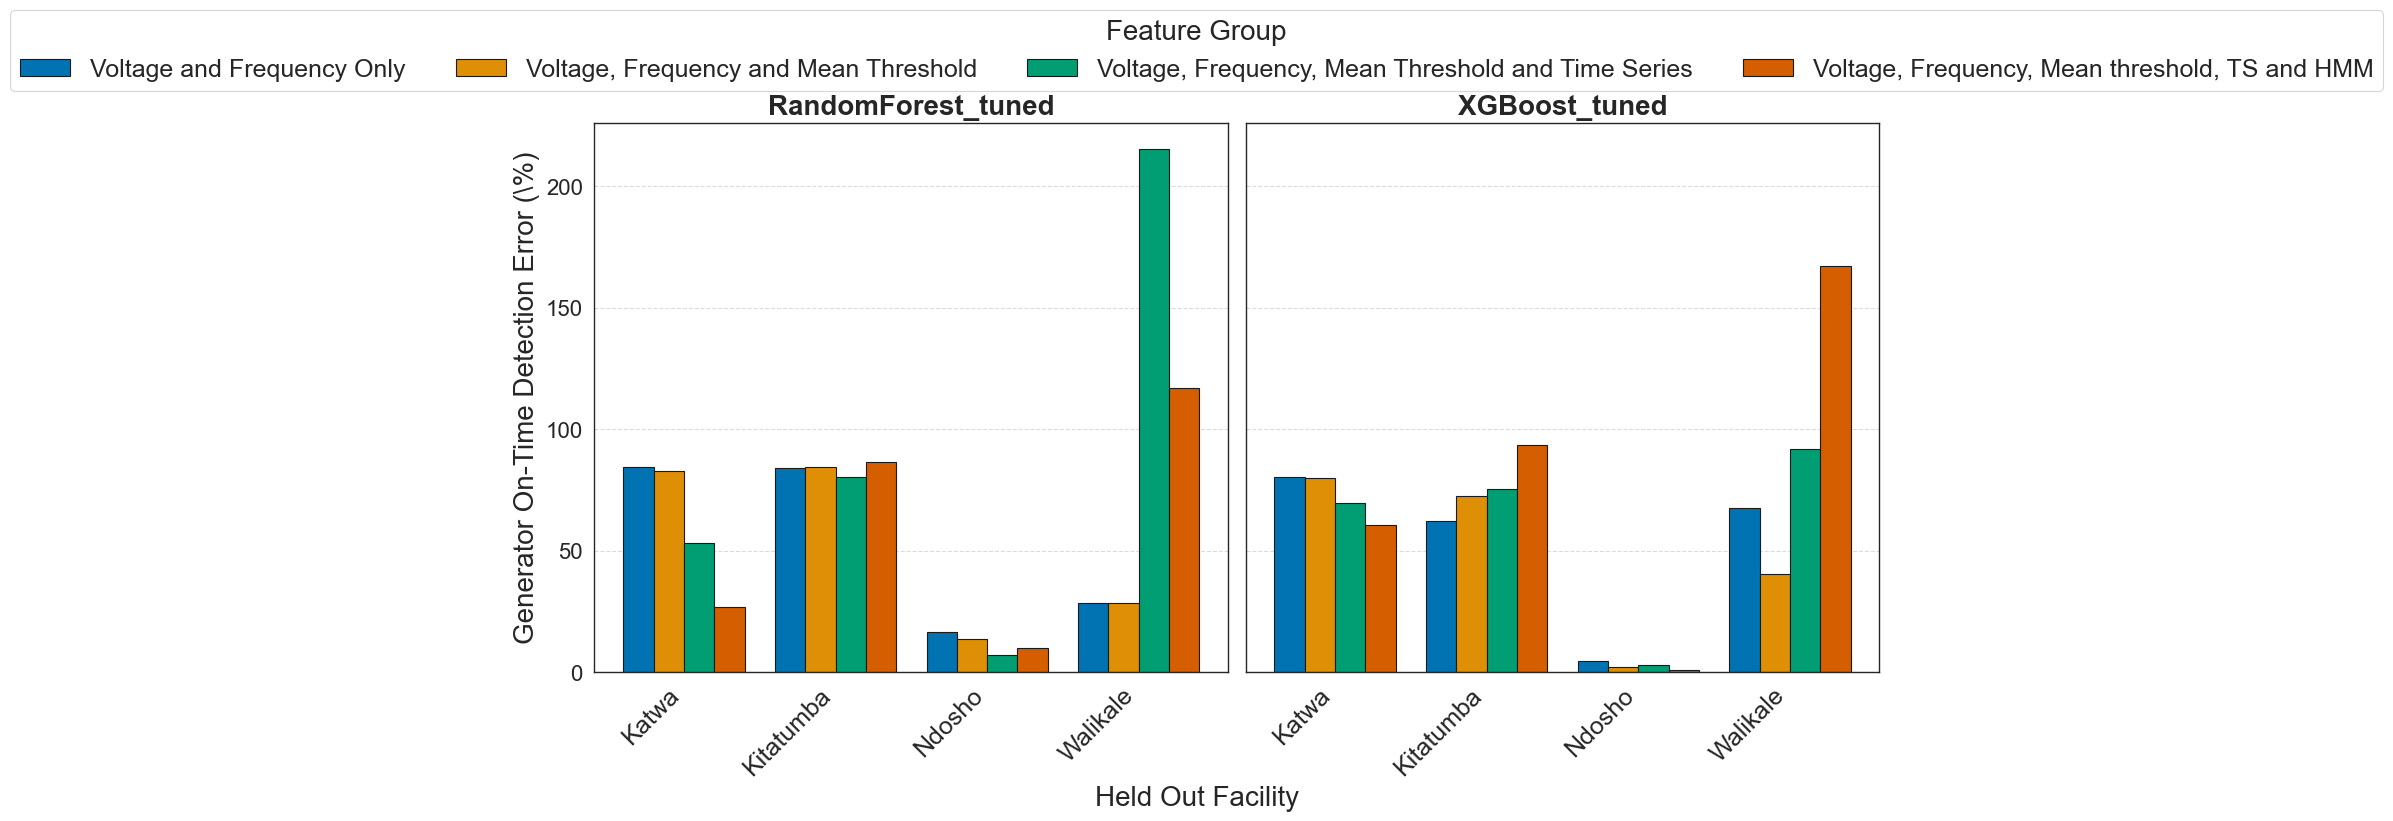

In [20]:
import os
#  Plot setup: one subplot per model (horizontal layout)
savepath = "/Users/sylviaimanirakiza/Documents/GitHub/Generator_ML_Emission_Modeling/Modeling/summer25_results/cross_site_models/"
# "plots_and_results/crosssitemodels"
os.makedirs(savepath, exist_ok=True)
# Use the cross_site DataFrame for plotting
df = results_crossval_partialintest_tuning

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl
import os

# Global Plot Styling
mpl.rcParams.update({
    'font.family': 'Arial',
    'axes.titlesize': 22,
    'axes.labelsize': 22,
    'xtick.labelsize': 24,
    'ytick.labelsize': 24,
    'legend.fontsize': 22,
    'figure.titlesize': 24
})
sns.set_style("white")
sns.despine(trim=True)

# Data filtering

models_of_interest = ['RandomForest_tuned', 'XGBoost_tuned']
# models_of_interest = ['RandomForest', 'XGBoost']
df_filtered = df[df['model'].isin(models_of_interest)].copy()
df_filtered['abs_gen_error'] = df_filtered['Percentage generator on-time detection error'].abs()

# Define categories
feature_groups = sorted(df_filtered['featuregroup'].unique())
print(feature_groups)
facilities = sorted(df_filtered['heldout_site'].unique())

# Color palette for feature groups
palette_fg = dict(zip(feature_groups, sns.color_palette("colorblind", len(feature_groups))))

# Save path setup
os.makedirs(savepath, exist_ok=True)

fig, axes = plt.subplots(1, len(models_of_interest), figsize=(7 * len(models_of_interest), 8), sharey=True)

if len(models_of_interest) == 1:
    axes = [axes]  # Ensure iterable

for ax, model in zip(axes, models_of_interest):
    df_model = df_filtered[df_filtered['model'] == model]

    # Aggregate data: mean and std of abs_gen_error grouped by facility & feature group
    summary = df_model.groupby(['heldout_site', 'featuregroup'])['abs_gen_error'].agg(['mean', 'std']).reset_index()

    # Pivot for grouped barplot (mean as height)
    pivot_mean = summary.pivot(index='heldout_site', columns='featuregroup', values='mean')
    pivot_std = summary.pivot(index='heldout_site', columns='featuregroup', values='std')

    # Facilities as x axis positions
    x = np.arange(len(facilities))
    total_width = 0.8
    n_bars = len(feature_groups)
    bar_width = total_width / n_bars

    for i, fg in enumerate(feature_groups):
        means = pivot_mean[fg].reindex(facilities)
        stds = pivot_std[fg].reindex(facilities)
        bars = ax.bar(x + i*bar_width, means, width=bar_width, yerr=stds, capsize=5,
                      label=fg, color=palette_fg[fg], edgecolor='k')

    ax.set_title(f"{model}", fontsize=20, fontweight='bold')
    ax.set_xticks(x + total_width/2 - bar_width/2)
    ax.set_xticklabels(facilities, fontsize=18, rotation=45, ha='right')
    ax.tick_params(axis='y', labelsize=16)
    ax.set_ylim(0, None)
    ax.grid(axis='y', linestyle='--', alpha=0.7)
    ax.minorticks_on()
    if ax == axes[0]:
        ax.set_ylabel("Generator On-Time Detection Error (\%)", fontsize=20)

    # Remove individual subplot legends
    ax.legend_.remove() if ax.get_legend() else None

# Shared legend (collect from one subplot)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    title="Feature Group",
    title_fontsize=20,
    fontsize=18,
    loc='upper center',
    bbox_to_anchor=(0.5, 1.05),
    ncol=len(feature_groups),
    frameon=True
)

# Shared x-axis label
fig.text(0.5, 0.04, 'Held Out Facility', ha='center', fontsize=20)

# Layout adjustments
plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.savefig(f'{savepath}/Generror_With_HMM features_Cross site_tuned.png', dpi=300, bbox_inches='tight')
plt.show()


['Voltage and Frequency Only', 'Voltage, Frequency and Mean Threshold', 'Voltage, Frequency, Mean Threshold and Time Series', 'Voltage, Frequency, Mean threshold, TS and HMM']


<Figure size 640x480 with 0 Axes>

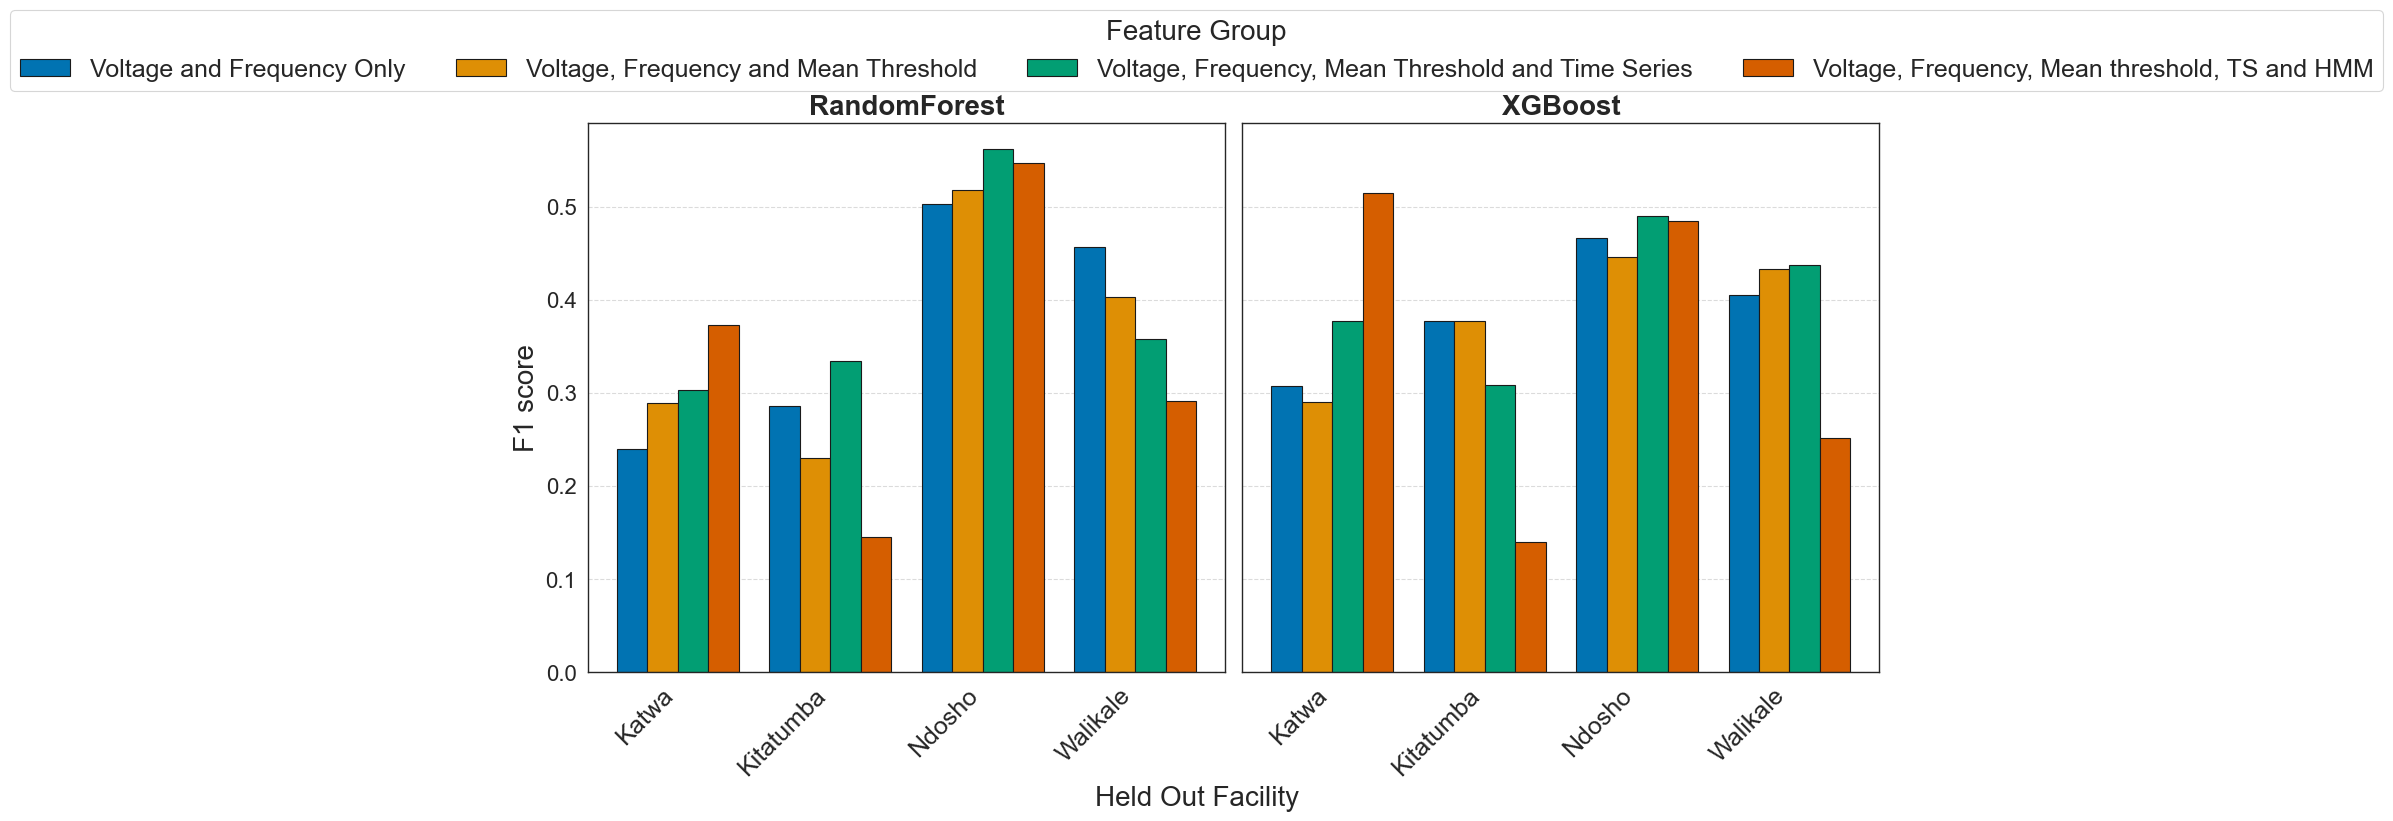

In [15]:
import os
#  Plot setup: one subplot per model (horizontal layout)
savepath = "/Users/sylviaimanirakiza/Documents/GitHub/Generator_ML_Emission_Modeling/Modeling/summer25_results/cross_site_models/"
# "plots_and_results/crosssitemodels"
os.makedirs(savepath, exist_ok=True)
# Use the cross_site DataFrame for plotting
df = results_crossval_partialintest_notuning

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl
import os

# Global Plot Styling
mpl.rcParams.update({
    'font.family': 'Arial',
    'axes.titlesize': 22,
    'axes.labelsize': 22,
    'xtick.labelsize': 24,
    'ytick.labelsize': 24,
    'legend.fontsize': 22,
    'figure.titlesize': 24
})
sns.set_style("white")
sns.despine(trim=True)

# Data filtering
models_of_interest = ['RandomForest', 'XGBoost']
df_filtered = df[df['model'].isin(models_of_interest)].copy()
# df_filtered['abs_gen_error'] = df_filtered['Percentage generator on-time detection error'].abs()

# Define categories
feature_groups = sorted(df_filtered['featuregroup'].unique())
print(feature_groups)
facilities = sorted(df_filtered['heldout_site'].unique())

# Color palette for feature groups
palette_fg = dict(zip(feature_groups, sns.color_palette("colorblind", len(feature_groups))))

# Save path setup
os.makedirs(savepath, exist_ok=True)

fig, axes = plt.subplots(1, len(models_of_interest), figsize=(7 * len(models_of_interest), 8), sharey=True)

if len(models_of_interest) == 1:
    axes = [axes]  # Ensure iterable

for ax, model in zip(axes, models_of_interest):
    df_model = df_filtered[df_filtered['model'] == model]

    # Aggregate data: mean and std of abs_gen_error grouped by facility & feature group
    summary = df_model.groupby(['heldout_site', 'featuregroup'])['f1 score'].agg(['mean', 'std']).reset_index()

    # Pivot for grouped barplot (mean as height)
    pivot_mean = summary.pivot(index='heldout_site', columns='featuregroup', values='mean')
    pivot_std = summary.pivot(index='heldout_site', columns='featuregroup', values='std')

    # Facilities as x axis positions
    x = np.arange(len(facilities))
    total_width = 0.8
    n_bars = len(feature_groups)
    bar_width = total_width / n_bars

    for i, fg in enumerate(feature_groups):
        means = pivot_mean[fg].reindex(facilities)
        stds = pivot_std[fg].reindex(facilities)
        bars = ax.bar(x + i*bar_width, means, width=bar_width, yerr=stds, capsize=5,
                      label=fg, color=palette_fg[fg], edgecolor='k')

    ax.set_title(f"{model}", fontsize=20, fontweight='bold')
    ax.set_xticks(x + total_width/2 - bar_width/2)
    ax.set_xticklabels(facilities, fontsize=18, rotation=45, ha='right')
    ax.tick_params(axis='y', labelsize=16)
    ax.set_ylim(0, None)
    ax.grid(axis='y', linestyle='--', alpha=0.7)
    ax.minorticks_on()
    if ax == axes[0]:
        ax.set_ylabel("F1 score", fontsize=20)

    # Remove individual subplot legends
    ax.legend_.remove() if ax.get_legend() else None

# Shared legend (collect from one subplot)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    title="Feature Group",
    title_fontsize=20,
    fontsize=18,
    loc='upper center',
    bbox_to_anchor=(0.5, 1.05),
    ncol=len(feature_groups),
    frameon=True
)

# Shared x-axis label
fig.text(0.5, 0.04, 'Held Out Facility', ha='center', fontsize=20)

# Layout adjustments
plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.savefig(f'{savepath}/F1score_With_HMM features_Cross site.png', dpi=300, bbox_inches='tight')
plt.show()

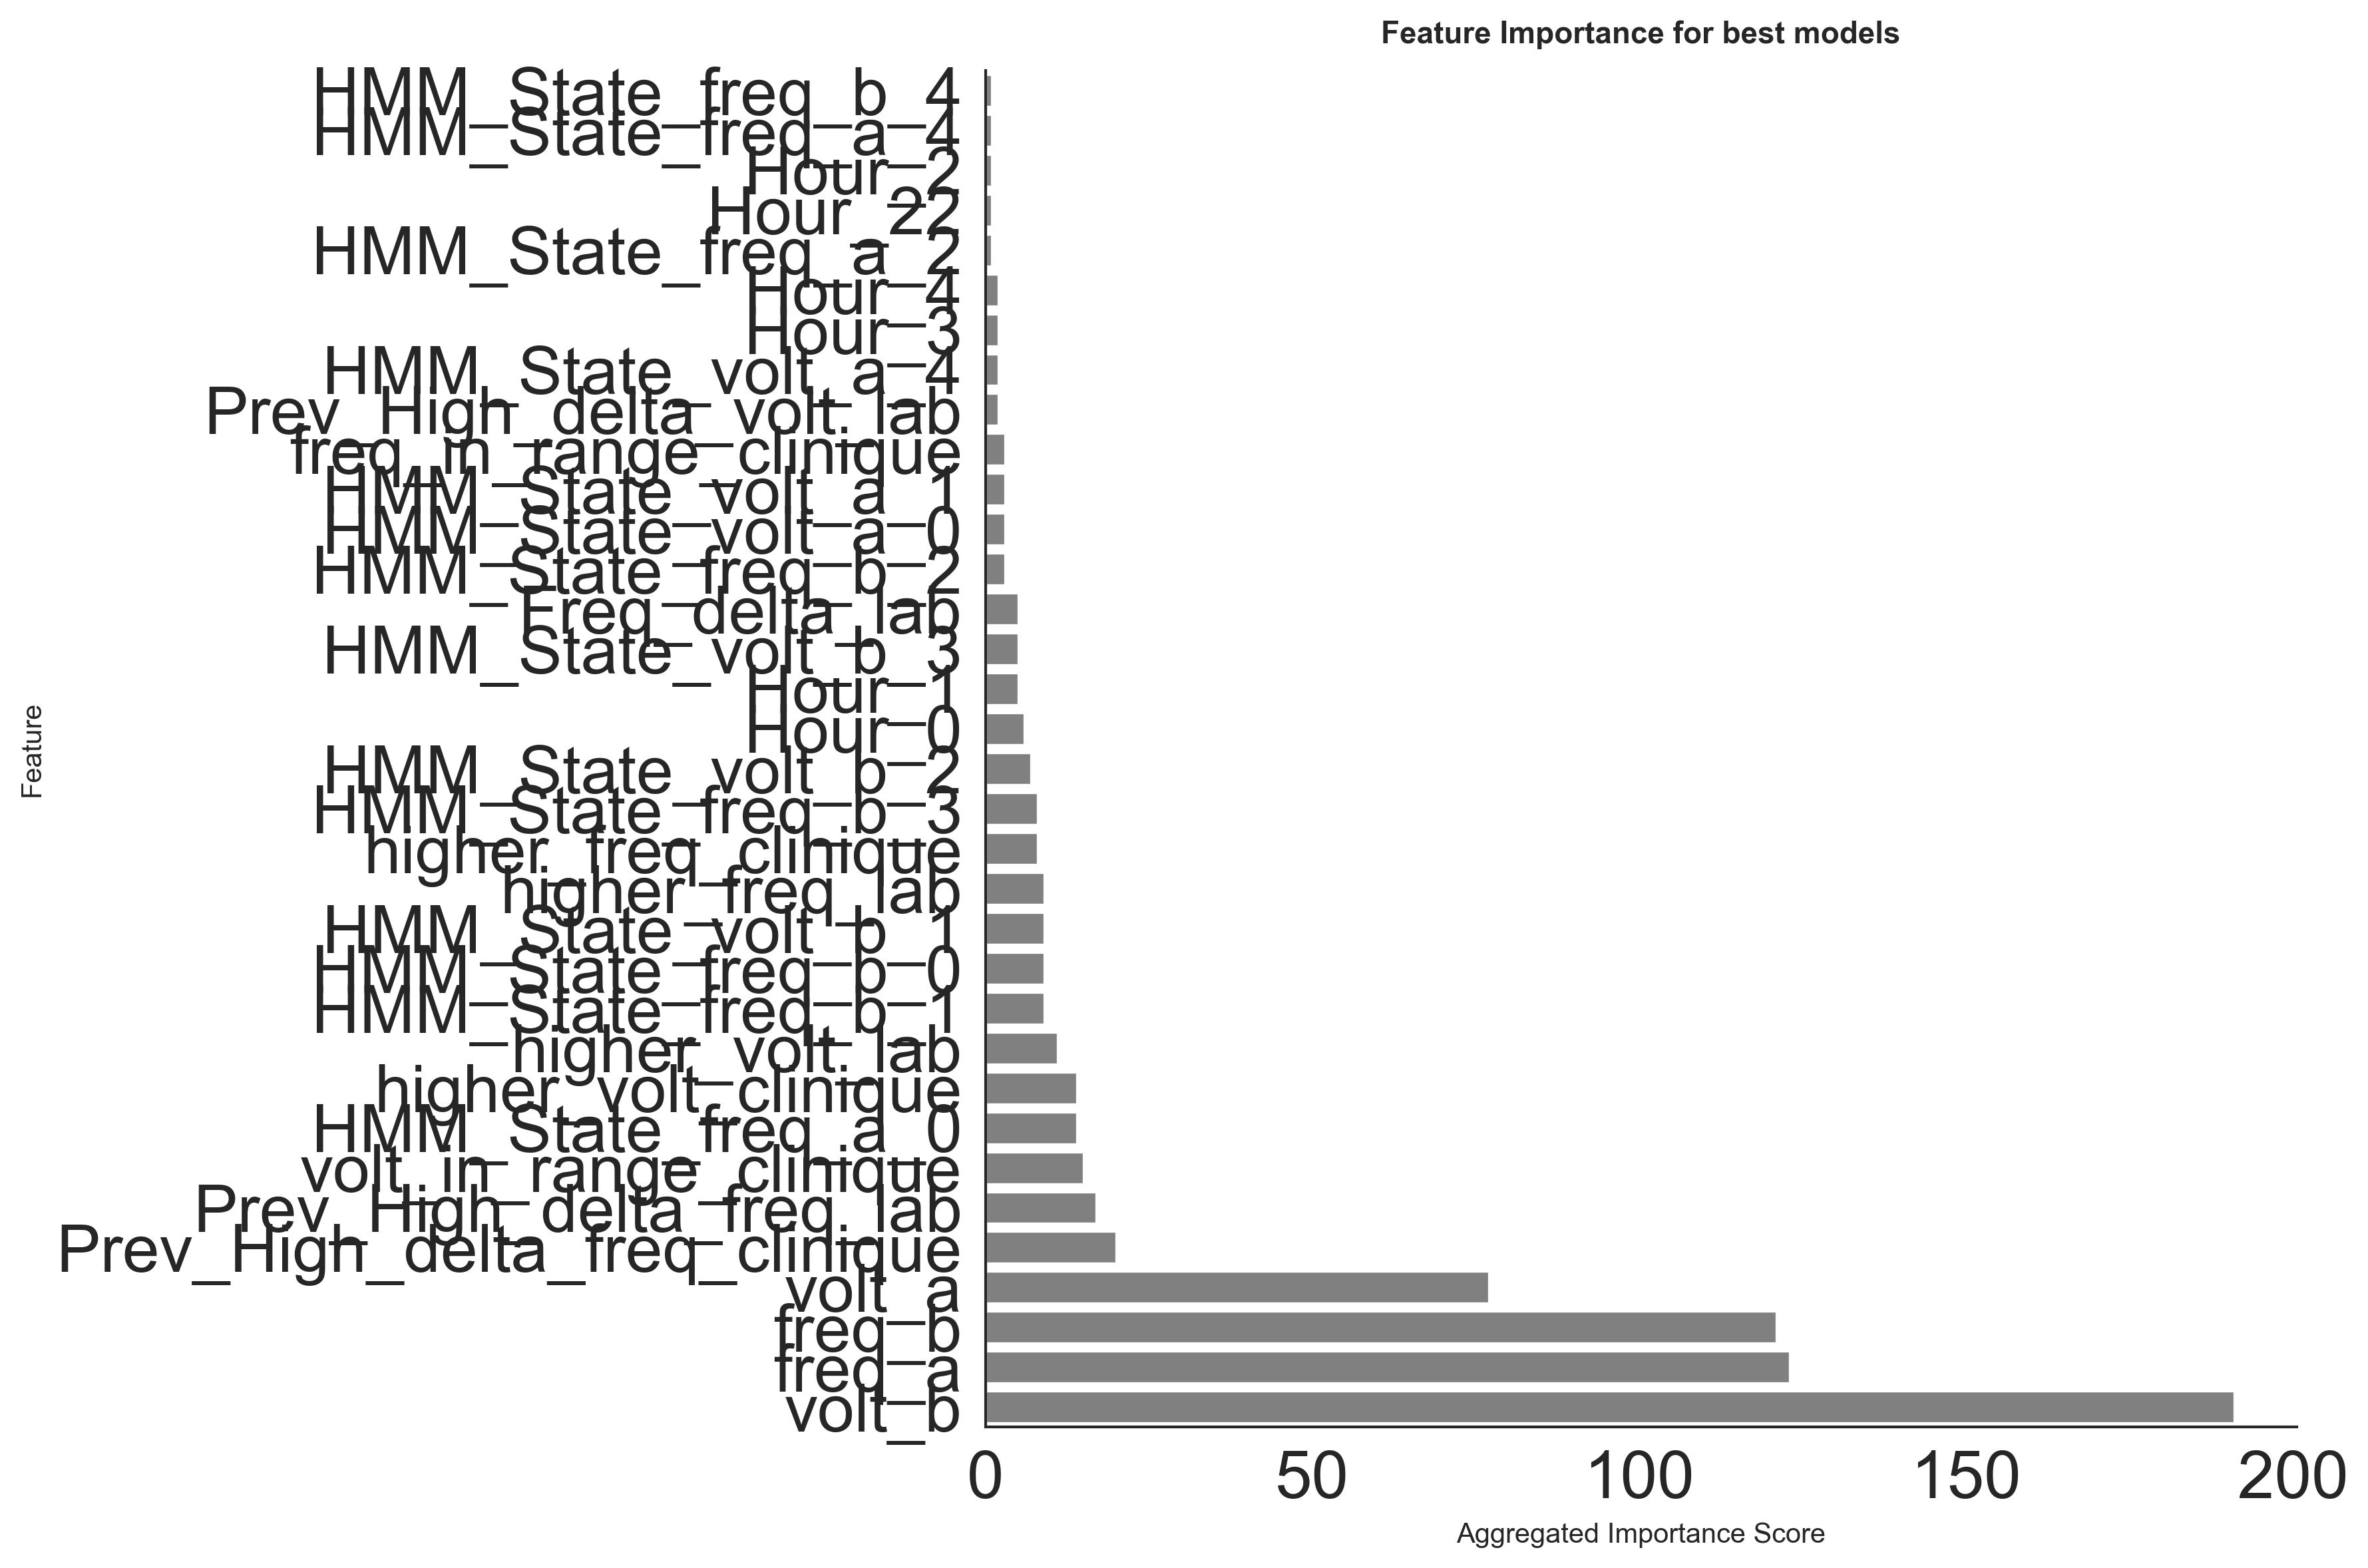

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict

savepath = "/Users/sylviaimanirakiza/Documents/GitHub/Generator_ML_Emission_Modeling/Modeling/summer25_results/cross_site_models/"
# "plots_and_results/crosssitemodels"
os.makedirs(savepath, exist_ok=True)
# Use the cross_site DataFrame for plotting
df = results_crossval_partialintest_notuning

# Filter for one model
model_name = "XGBoost"  # Change to the model you want to analyze
feature_group_option = "Voltage, Frequency, Mean threshold, TS and HMM"  # Change to the feature group you want to analyze
# siteselect = 'Ndosho'  # Change to the site you want to analyze 
df_model = df
all_scores_df = df_model
best_models_df = all_scores_df.sort_values("f1 score", ascending=False).drop_duplicates("heldout_site")

# Score mapping (rank-based)
position_scores = {0: 5, 1: 4, 2: 3, 3: 2, 4: 1}
feature_scores = defaultdict(int)

# Aggregate scores
for features_str in df_model['top5_features'].dropna():
    features = [f.strip() for f in features_str.split(",")]
    for i, feat in enumerate(features):
        if i < 5:
            feature_scores[feat] += position_scores[i]

# Convert to DataFrame
feat_df = pd.DataFrame(list(feature_scores.items()), columns=["Feature", "Score"])
feat_df = feat_df.sort_values(by="Score", ascending=True)  # for horizontal bar

# Plot settings
# sns.set(style="whitegrid", context="paper", font="serif", font_scale=1.2)
plt.figure(figsize=(12, 8), dpi=300)

# Use grayscale or accessible color palette
sns.barplot(data=feat_df, x="Score", y="Feature", color="gray")

# Labels and title
plt.xlabel("Aggregated Importance Score", fontsize=10)
plt.ylabel("Feature", fontsize=10)
plt.title(f"Feature Importance for best models", fontsize=11, weight="bold", pad=10)

# Remove spines and tighten layout
sns.despine()
plt.tight_layout()

# Save for IEEE (as .pdf or .eps for LaTeX)
plt.savefig(f"{savepath}/feature_importance_bestmodels.png", format='png', dpi=300, bbox_inches='tight')
# Save the figure

# Optional: Display
plt.show()


/var/folders/jt/h9jl_c652pq4xqxwj_k7x_7r0000gp/T/ipykernel_15153/1093250384.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feature_importance_df, y="feature", x="normalized_score", palette="viridis")


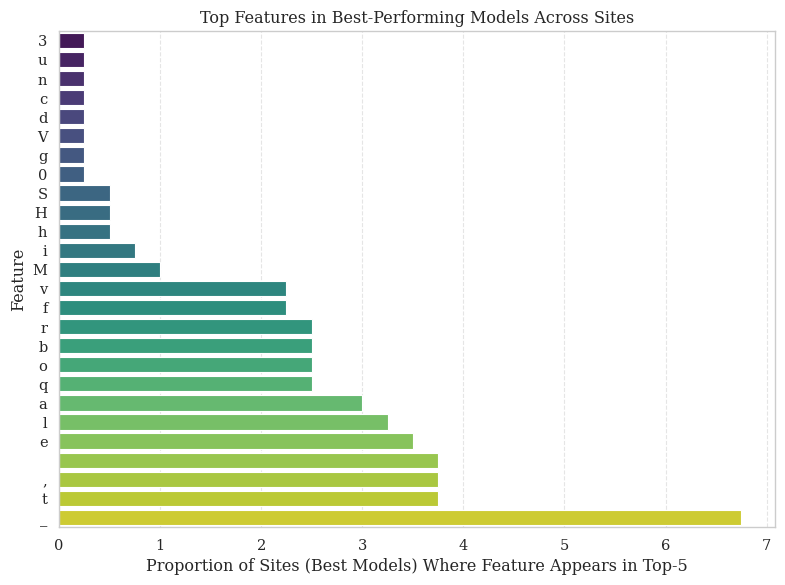

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Load your full results table
#    result = {
#                     "experiment_type": "modified loso" if train_portion < 1.0 else "original_loso",
#                     "heldout_site": test_site,
#                     "model": model_name,
#                     "featuregroup": group,
#                     "hyperparameter_tuning": tune_hyperparams,
#                     "top5_features": top_feature_str,
#                     "trainset_size": len(X_train),
#                     "testset_size": len(X_test),
#                     "train_accuracy": train_metrics["Accuracy"],
#                     "test_accuracy": test_metrics["Accuracy"],
#                     "precision": test_metrics["Precision"],
#                     "recall": test_metrics["Recall"],
#                     "f1 score": test_metrics.get("F1_Score", 0),
#                     "actual_mins_GENON": actual_minutes,
#                     "predicted_mins_GENON": predicted_minutes,
#                     "Percentage generator on-time detection error": -(100*(actual_minutes-predicted_minutes))/actual_minutes if actual_minutes > 0 else 0
#                 }
all_scores_df = df

# Sample columns expected: ["heldout_site", "model", "features", "f1", "top_5_features"]
# If `top_5_features` is a string of list (e.g. "['freq_a_std', 'volt_b_min']", use `ast.literal_eval` to convert to list
import ast
# all_scores_df["top5_features"] = all_scores_df["top5_features"].apply(ast.literal_eval)

# Step 2: Get the best model per site based on F1 score
best_models_df = all_scores_df.sort_values("f1 score", ascending=False).drop_duplicates("heldout_site")

# Step 3: Flatten all top 5 features from the best models
from collections import Counter
feature_counter = Counter()

for feature_list in best_models_df["top5_features"]:
    feature_counter.update(feature_list)

# Step 4: Convert to DataFrame for plotting
feature_importance_df = pd.DataFrame(feature_counter.items(), columns=["feature", "count"])
feature_importance_df["normalized_score"] = feature_importance_df["count"] / best_models_df.shape[0]
feature_importance_df = feature_importance_df.sort_values("normalized_score", ascending=True)

# Step 5: Plot
plt.figure(figsize=(8, 6))
sns.barplot(data=feature_importance_df, y="feature", x="normalized_score", palette="viridis")

plt.xlabel("Proportion of Sites (Best Models) Where Feature Appears in Top-5")
plt.ylabel("Feature")
plt.title("Top Features in Best-Performing Models Across Sites")
plt.tight_layout()
plt.grid(True, axis="x", linestyle="--", alpha=0.5)

# Save high-resolution for IEEE format
plt.savefig(f"{savepath}/best_model_feature_importance.png", dpi=600)
plt.show()
